In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import ResNet50
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [ ]:
dataset_name = "cats_vs_dogs"
(train_ds, val_ds, test_ds), dataset_info = tfds.load(dataset_name, split=["train[:70%]", "train[70%:85%]", "train[85%:]"], as_supervised=True, with_info=True)
# the error below is because I have split them previously

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

KeyError: "There is no item named 'PetImages\\\\Cat\\\\0.jpg' in the archive"

In [ ]:
import shutil
import os
from sklearn.model_selection import train_test_split

# Define the dataset path
dataset_directory = 'CatsVsDogs/PetImages'

# Ensure that Cat and Dog directories exist
cat_dir = os.path.join(dataset_directory, 'Cat')
dog_dir = os.path.join(dataset_directory, 'Dog')

# Get all files in both directories
cat_files = [os.path.join(cat_dir, f) for f in os.listdir(cat_dir) if os.path.isfile(os.path.join(cat_dir, f))]
dog_files = [os.path.join(dog_dir, f) for f in os.listdir(dog_dir) if os.path.isfile(os.path.join(dog_dir, f))]

# Combine the files into one list
all_files = cat_files + dog_files

# Check if there are files
if len(all_files) == 0:
    print("No images found in the dataset directories!")
    # they have already been split so just need to load them
    train_files = sorted((os.path.join(dataset_directory, 'train', 'cat', '*'))) + sorted((os.path.join(dataset_directory, 'train', 'dog', '*')))
    val_files = sorted((os.path.join(dataset_directory, 'val', 'cat', '*'))) + sorted((os.path.join(dataset_directory, 'val', 'dog', '*')))
    test_files = sorted((os.path.join(dataset_directory, 'test', 'cat', '*'))) + sorted((os.path.join(dataset_directory, 'test', 'dog', '*')))

else:
    print(f"Found {len(all_files)} images in total.")

    # Split into train, validation, and test
    train_files, test_val_files = train_test_split(all_files, test_size=0.3, random_state=123)
    val_files, test_files = train_test_split(test_val_files, test_size=0.5, random_state=123)  # 50% of remaining for validation and test

    # Move files to respective directories
    for file in train_files:
        category = 'Cat' if 'Cat' in file else 'Dog'
        shutil.move(file, os.path.join(dataset_directory, 'train', category, os.path.basename(file)))
    for file in val_files:
        category = 'Cat' if 'Cat' in file else 'Dog'
        shutil.move(file, os.path.join(dataset_directory, 'val', category, os.path.basename(file)))
    for file in test_files:
        category = 'Cat' if 'Cat' in file else 'Dog'
        shutil.move(file, os.path.join(dataset_directory, 'test', category, os.path.basename(file)))


No images found in the dataset directories!


In [ ]:
# move the data into datasets
train_ds = tf.data.Dataset.from_tensor_slices(train_files)
val_ds = tf.data.Dataset.from_tensor_slices(val_files)
test_ds = tf.data.Dataset.from_tensor_slices(test_files)

In [ ]:
# adjust the data to the correct shape and type
def format_data(image, label):
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, (150, 150))
    image = tf.cast(image, tf.float32) / 255.0 
    return image, label

In [ ]:
# get the labels given the paths
def get_file_paths_and_labels(image_dir):
    file_paths = []
    labels = []
    for category in ['Cat', 'Dog']:
        category_dir = os.path.join(image_dir, category)
        for filename in os.listdir(category_dir):
            file_paths.append(os.path.join(category_dir, filename))
            labels.append(0 if category == 'Cat' else 1)  # Label 0 for Cat, 1 for Dog
    return file_paths, labels

In [ ]:

def load_and_decode(file_path, label):
    try:
        # Read the image file
        image = tf.io.read_file(file_path)  
        # Decode the image (works for all formats)
        image = tf.image.decode_image(image, channels=3)  
        
        # Check if the image is valid (has 3 channels)
        if image.shape[-1] != 3:
            image = tf.zeros([150, 150, 3], dtype=tf.uint8)  # Return an empty tensor for invalid images

    except tf.errors.InvalidArgumentError as e:
        print(f"Error reading {file_path}: {e}")
        image = tf.zeros([150, 150, 3], dtype=tf.uint8)
    return image, label

In [11]:
train_files, train_labels = get_file_paths_and_labels('CatsVsDogs/PetImages/train')
val_files, val_labels = get_file_paths_and_labels('CatsVsDogs/PetImages/val')
test_files, test_labels = get_file_paths_and_labels('CatsVsDogs/PetImages/test')

In [12]:
train_ds = tf.data.Dataset.from_tensor_slices((train_files, train_labels))
val_ds = tf.data.Dataset.from_tensor_slices((val_files, val_labels))
test_ds = tf.data.Dataset.from_tensor_slices((test_files, test_labels))

train_ds = train_ds.map(load_and_decode).map(format_data).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(load_and_decode).map(format_data).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(load_and_decode).map(format_data).batch(32).prefetch(tf.data.AUTOTUNE)

conv_base = ResNet50(weights='imagenet', include_top=False, input_shape=(150,150,3))
conv_base.trainable = False

In [13]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal", input_shape=(150, 150, 3)),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomWidth(0.2),
    layers.RandomHeight(0.2),
])

C:\Users\panda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
inputs = keras.Input(shape=(150,150,3))
x = data_augmentation(inputs)
x = conv_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu',kernel_regularizer=regularizers.l2( l2=0.01))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer=keras.optimizers.Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss")
]

history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 124s 336ms/step - accuracy: 0.9929 - loss: 3.2188 - val_accuracy: 1.0000 - val_loss: 0.7332
Epoch 2/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 117s 329ms/step - accuracy: 1.0000 - loss: 0.4993 - val_accuracy: 1.0000 - val_loss: 0.1389
Epoch 3/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 122s 343ms/step - accuracy: 1.0000 - loss: 0.1060 - val_accuracy: 1.0000 - val_loss: 0.0477
Epoch 4/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 119s 336ms/step - accuracy: 1.0000 - loss: 0.0397 - val_accuracy: 1.0000 - val_loss: 0.0223
Epoch 5/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 116s 326ms/step - accuracy: 1.0000 - loss: 0.0193 - val_accuracy: 1.0000 - val_loss: 0.0119
Epoch 6/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 116s 326ms/step - accuracy: 1.0000 - loss: 0.0106 - val_accuracy: 1.0000 - val_loss: 0.0069
Epoch 7/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 115s 325ms/step - accuracy: 1.0000 - loss: 0.0064 - val_accuracy: 1.0000 - val_loss: 0.0043
Epoch 8/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 117s 330ms/step - accuracy: 1.0000 -

In [ ]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

conv_base.trainable = True
for layer in conv_base.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-6), loss='binary_crossentropy', metrics=['accuracy'])

history_fine = model.fit(train_ds, epochs=10, validation_data=val_ds, callbacks=callbacks)

Epoch 1/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 114s 321ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 2/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 115s 323ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 8.0549e-04
Epoch 3/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 115s 325ms/step - accuracy: 1.0000 - loss: 8.5384e-04 - val_accuracy: 1.0000 - val_loss: 6.2812e-04
Epoch 4/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 115s 324ms/step - accuracy: 1.0000 - loss: 6.7010e-04 - val_accuracy: 1.0000 - val_loss: 4.8005e-04
Epoch 5/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 112s 316ms/step - accuracy: 1.0000 - loss: 5.3676e-04 - val_accuracy: 1.0000 - val_loss: 3.7613e-04
Epoch 6/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 112s 316ms/step - accuracy: 1.0000 - loss: 4.3544e-04 - val_accuracy: 1.0000 - val_loss: 3.1106e-04
Epoch 7/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 111s 313ms/step - accuracy: 1.0000 - loss: 3.6213e-04 - val_accuracy: 1.0000 - val_loss: 2.6357e-04
Epoch 8/10
355/355 ━━━━━━━━━━━━━

In [ ]:
conv_base.trainable = True
for layer in conv_base.layers[:-20]:
  layer.trainable = False

model.compile(optimizer=keras.optimizers.RMSprop(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss")
]
history_fin = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=callbacks)

Epoch 1/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 146s 398ms/step - accuracy: 1.0000 - loss: 5.4623e-05 - val_accuracy: 1.0000 - val_loss: 8.0626e-05
Epoch 2/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 142s 401ms/step - accuracy: 1.0000 - loss: 5.3824e-05 - val_accuracy: 1.0000 - val_loss: 8.1287e-05
Epoch 3/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 141s 398ms/step - accuracy: 1.0000 - loss: 5.3291e-05 - val_accuracy: 1.0000 - val_loss: 7.2053e-05
Epoch 4/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 140s 395ms/step - accuracy: 1.0000 - loss: 5.3344e-05 - val_accuracy: 1.0000 - val_loss: 7.3369e-05
Epoch 5/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 140s 396ms/step - accuracy: 1.0000 - loss: 5.3490e-05 - val_accuracy: 1.0000 - val_loss: 6.8893e-05
Epoch 6/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 139s 393ms/step - accuracy: 1.0000 - loss: 5.2662e-05 - val_accuracy: 1.0000 - val_loss: 7.0032e-05
Epoch 7/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 141s 398ms/step - accuracy: 1.0000 - loss: 5.1726e-05 - val_accuracy: 1.0000 - val_loss: 7.2958e-05
Epoch 8/10
355/355 ━

In [ ]:
conv_base.trainable = True
for layer in conv_base.layers[:-10]:
  layer.trainable = False

model.compile(optimizer=keras.optimizers.SGD(1e-5), loss='binary_crossentropy', metrics=['accuracy'])

history_fin = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=callbacks)

Epoch 1/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 131s 359ms/step - accuracy: 1.0000 - loss: 5.1016e-05 - val_accuracy: 1.0000 - val_loss: 6.1588e-05
Epoch 2/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 142s 359ms/step - accuracy: 1.0000 - loss: 5.2424e-05 - val_accuracy: 1.0000 - val_loss: 6.1617e-05
Epoch 3/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 126s 356ms/step - accuracy: 1.0000 - loss: 4.9713e-05 - val_accuracy: 1.0000 - val_loss: 6.2672e-05
Epoch 4/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 127s 359ms/step - accuracy: 1.0000 - loss: 5.2327e-05 - val_accuracy: 1.0000 - val_loss: 5.9981e-05
Epoch 5/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 126s 355ms/step - accuracy: 1.0000 - loss: 5.1918e-05 - val_accuracy: 1.0000 - val_loss: 6.0796e-05
Epoch 6/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 126s 356ms/step - accuracy: 1.0000 - loss: 5.0773e-05 - val_accuracy: 1.0000 - val_loss: 6.0274e-05
Epoch 7/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 128s 360ms/step - accuracy: 1.0000 - loss: 5.0602e-05 - val_accuracy: 1.0000 - val_loss: 5.9872e-05
Epoch 8/10
355/355 ━

In [ ]:
model = keras.models.load_model("fine_tuning.keras")
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.3f}")

109/109 ━━━━━━━━━━━━━━━━━━━━ 28s 244ms/step - accuracy: 1.0000 - loss: 5.9872e-05
Test accuracy: 1.000


In [ ]:
def plot_history(history, history_fine):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Initial Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Initial Val Accuracy')
    plt.plot(history_fine.history['accuracy'], label='Fine-tune Train Accuracy')
    plt.plot(history_fine.history['val_accuracy'], label='Fine-tune Val Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Initial Train Loss')
    plt.plot(history.history['val_loss'], label='Initial Val Loss')
    plt.plot(history_fine.history['loss'], label='Fine-tune Train Loss')
    plt.plot(history_fine.history['val_loss'], label='Fine-tune Val Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.show()

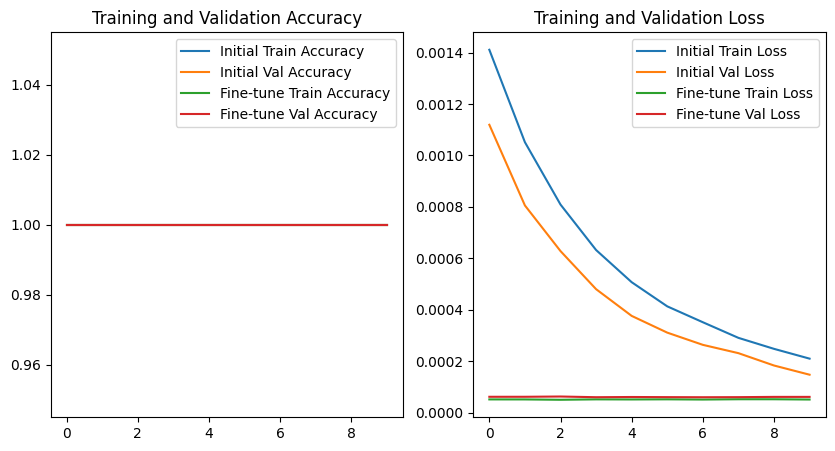

In [ ]:
plot_history(history, history_fin)